<a href="https://colab.research.google.com/github/LordAguaKate/Telecom2/blob/main/Telecom2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import json

In [12]:
ruta_json = 'TelecomX_Data.json'

In [13]:
try:
    # 1. Cargar el archivo JSON bruto
    with open(ruta_json, 'r') as archivo:
        datos_brutos = json.load(archivo)

    # 2. Aplanar la estructura anidada (flattening)
    df = pd.json_normalize(datos_brutos)

    # 3. Limpieza de nombres de columnas
    # json_normalize crea nombres como 'account.Charges.Total'.
    # Para simplificar, nos quedamos solo con la última parte del nombre.
    df.columns = [col.split('.')[-1] for col in df.columns]

    # 4. Corrección de tipos de datos (replicando la limpieza de la Parte 1)
    # Convertimos 'Total' a numérico y rellenamos los valores vacíos con 0
    df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
    df['Total'].fillna(0, inplace=True)

    print(f"¡Datos extraídos y aplanados con éxito!")
    print(f"Dimensiones del DataFrame: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

    # Visualizamos las primeras filas para confirmar
    display(df.head())

except FileNotFoundError:
    print("⚠️ Error: No se encontró el archivo 'TelecomX_Data.json'.")
    print("Asegúrate de haberlo subido a la carpeta /content/ de Google Colab.")

¡Datos extraídos y aplanados con éxito!
Dimensiones del DataFrame: 7267 filas y 21 columnas.



/tmp/ipykernel_210/2202404482.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total'].fillna(0, inplace=True)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


# **Purgar Identificadores**
Desde la perspectiva del Machine Learning, incluir identificadores únicos como el customerID es una mala práctica. Dado que cada valor es único (alta cardinalidad), algoritmos como los Árboles de Decisión o Random Forest podrían intentar "memorizar" estos IDs en lugar de aprender los patrones reales de los datos, lo que irremediablemente nos llevaría a un problema de overfitting (sobreajuste). En modelos lineales, simplemente no aportan ninguna varianza útil.

In [14]:
# Eliminación de identificadores únicos para evitar ruido y sobreajuste en los modelos
columna_id = 'customerID'

if columna_id in df.columns:
    df = df.drop(columns=[columna_id])
    print(f"La columna '{columna_id}' ha sido eliminada con éxito.")
else:
    print(f"La columna '{columna_id}' ya no se encuentra en el DataFrame.")

# Verificamos las nuevas dimensiones y el estado de los datos
print(f"Nuevas dimensiones del DataFrame: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
display(df.head(3))

La columna 'customerID' ha sido eliminada con éxito.
Nuevas dimensiones del DataFrame: 7267 filas y 20 columnas.



,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


Al ejecutar esto, nuestro dataset quedará exclusivamente con variables que describen el comportamiento, las características demográficas y los servicios del cliente, que es exactamente donde reside el poder predictivo.

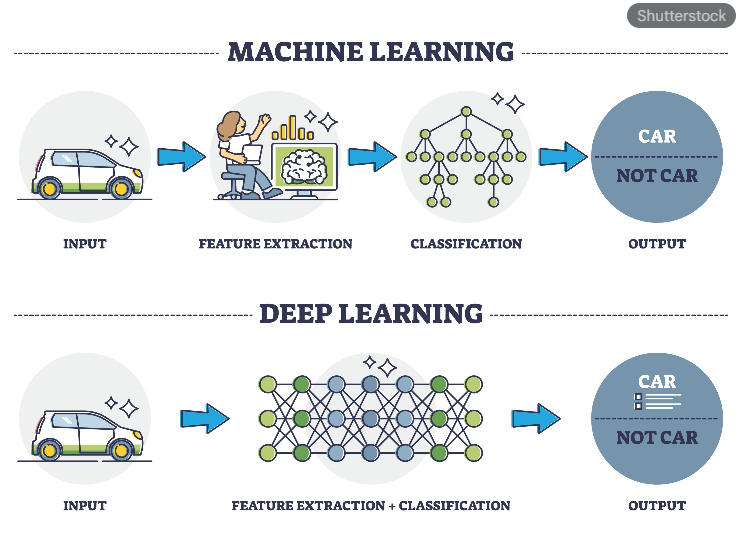

Una vez que hayamos retirado el ID, el siguiente paso clave será la Traducción y Codificación de Variables (Encoding). Tenemos muchas columnas con valores "Yes"/"No" o categorías de texto que nuestros modelos matemáticos no entenderán hasta que las convirtamos en números (0 y 1, por ejemplo).


# **Encoding**
Llegamos a uno de los puntos más críticos en la preparación de datos: el Encoding. Los modelos matemáticos (como la regresión o los árboles) no saben qué significa "Month-to-month" o "Fiber optic"; solo entienden de números.

Se va a dividir esta etapa en dos partes para tener un control total:

1. Codificación de la Variable Objetivo (Churn): Como es lo que queremos predecir, lo ideal es mapearla directamente de forma binaria (0 para 'No' y 1 para 'Yes'). Esto facilitará la interpretación de las métricas y la probabilidad.

2. One-Hot Encoding para las Variables Predictoras (Features): Utilizaremos pd.get_dummies(). Además, aplicaremos un truco de oro en la ciencia de datos: el parámetro drop_first=True. Esto evita un problema estadístico llamado multicolinealidad (o "trampa de las variables ficticias"), el cual puede arruinar los modelos de regresión lineal y logística al introducir información redundante.

In [15]:
# 1. Mapeo de la variable objetivo (Target)
# Convertimos explícitamente el 'Churn' a formato binario (0 y 1)
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
    print("Variable objetivo 'Churn' codificada con éxito (0 = No, 1 = Yes).")

# 2. One-Hot Encoding para las variables predictoras categóricas
# Identificamos las columnas que son de tipo 'object' (texto)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables categóricas a codificar: {columnas_categoricas}\n")

# Aplicamos get_dummies.
# drop_first=True elimina la primera categoría generada para evitar multicolinealidad.
# dtype=int asegura que el resultado sea 0 y 1 en lugar de True y False (en versiones recientes de pandas)
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

print("One-Hot Encoding aplicado con éxito.")
print(f"Nuevas dimensiones del DataFrame: {df_encoded.shape[0]} filas y {df_encoded.shape[1]} columnas.\n")

# Visualizamos el resultado final para confirmar
display(df_encoded.head(3))

Variable objetivo 'Churn' codificada con éxito (0 = No, 1 = Yes).
Variables categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

One-Hot Encoding aplicado con éxito.
Nuevas dimensiones del DataFrame: 7267 filas y 31 columnas.



,Churn,SeniorCitizen,tenure,Monthly,Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,0,1,1,1,0,...,0,1,0,0,1,0,1,0,0,1
1,0.0,0,9,59.9,542.40,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,1
2,1.0,0,4,73.9,280.85,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


# **Proporción de Cancelación**
Si tenemos un desbalanceo severo (por ejemplo, 80% de clientes que se quedan y 20% que se van), un modelo deficiente podría simplemente predecir que "nadie se va" y aún así obtener un 80% de precisión (accuracy). Sin embargo, para el negocio, ese modelo sería inútil porque no identificaría a los clientes en riesgo (tendría un Recall de 0% para la clase minoritaria).

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# 1. Calculamos el conteo absoluto y la proporción (porcentaje)
conteo_churn = df_encoded['Churn'].value_counts()
proporcion_churn = df_encoded['Churn'].value_counts(normalize=True) * 100

/tmp/ipykernel_210/563613201.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_encoded, x='Churn', palette=['#1ABC9C', '#E74C3C'])


--- Distribución de la variable objetivo (Churn) ---
Retenidos (0): 5174 clientes (73.46%)
Cancelados (1): 1869 clientes (26.54%)


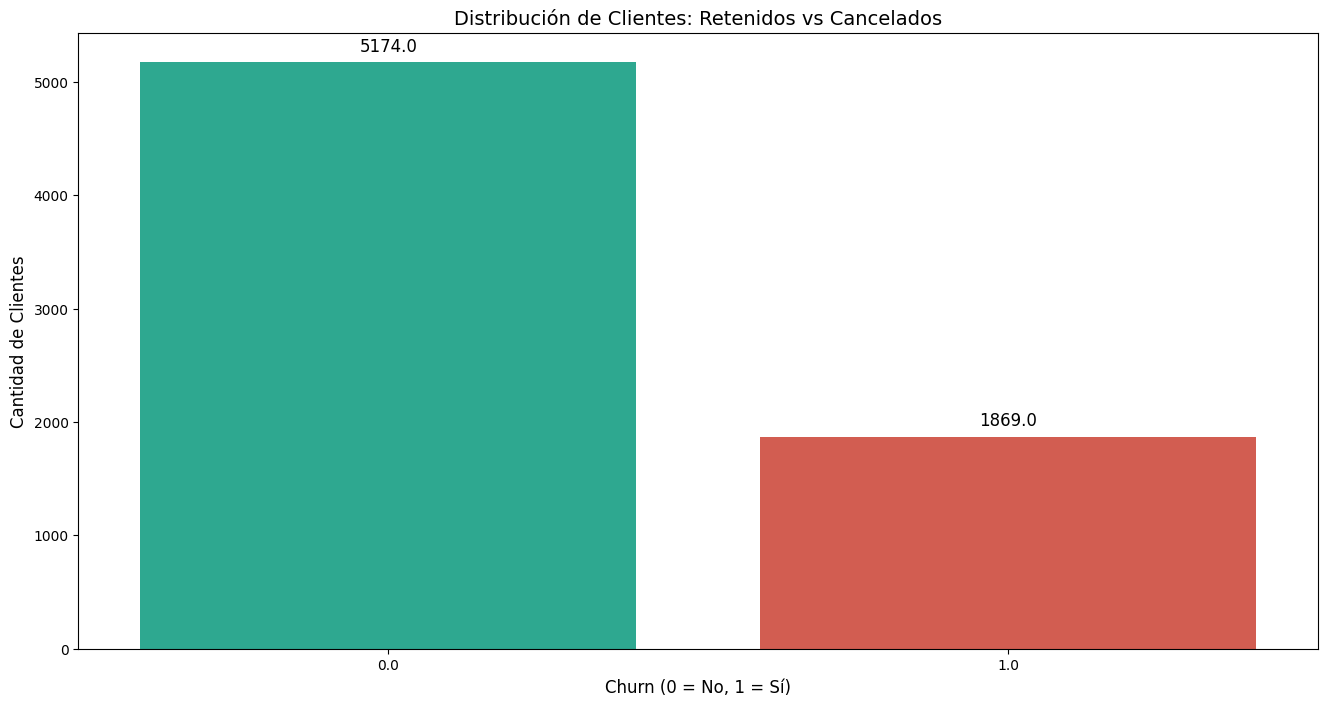

In [18]:
# Mostramos los resultados en texto
print("--- Distribución de la variable objetivo (Churn) ---")
print(f"Retenidos (0): {conteo_churn[0]} clientes ({proporcion_churn[0]:.2f}%)")
print(f"Cancelados (1): {conteo_churn[1]} clientes ({proporcion_churn[1]:.2f}%)")

# 2. Visualización rápida para el análisis descriptivo
plt.figure(figsize=(16, 8))
ax = sns.countplot(data=df_encoded, x='Churn', palette=['#1ABC9C', '#E74C3C'])
plt.title('Distribución de Clientes: Retenidos vs Cancelados', fontsize=14)
plt.xlabel('Churn (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Agregamos las etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

# **Diagnostico**
En la industria de telecomunicaciones, es muy común encontrar que la tasa de cancelación (churn rate) ronde entre el 20% y el 30%. Si tus resultados arrojan este comportamiento, significa que tenemos un dataset desbalanceado.

Para lidiar con esto en el modelado, tendremos que tomar decisiones estratégicas más adelante, como usar métricas de evaluación específicas (como F1-Score, Precision o Recall en lugar de solo Accuracy) o aplicar técnicas como el sobremuestreo (SMOTE) o el ajuste de pesos en nuestros algoritmos.

#**Balanceo**
el balanceo de clases (como SMOTE) siempre se aplica DESPUÉS de dividir los datos en entrenamiento y prueba, y solo sobre el conjunto de entrenamiento. Si aplicamos SMOTE antes de dividir, estaríamos filtrando información sintética al conjunto de prueba (data leakage), lo que nos daría métricas falsamente altas y un modelo que fracasaría en el mundo real.Vamos a matar dos pájaros de un tiro: dividiremos nuestros datos ($X$ e $y$) y aplicaremos SMOTE (Técnica de Sobremuestreo de Minorías Sintéticas) para igualar la cantidad de clientes que cancelaron con los que se quedaron, enseñándole al modelo a reconocer mejor los patrones de fuga.

In [19]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [21]:
# 1. Separar características (X) y variable objetivo (y)
# Eliminar filas donde la variable objetivo 'Churn' sea NaN
df_cleaned = df_encoded.dropna(subset=['Churn'])
X = df_cleaned.drop('Churn', axis=1)
y = df_cleaned['Churn']

# 2. División en Entrenamiento (Train) y Prueba (Test)
# Usamos stratify=y para mantener la proporción original en la división inicial
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Distribución ANTES de SMOTE (en set de entrenamiento):")
print(y_train.value_counts())
print("-" * 30)

# 3. Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. Verificamos el resultado
print(f"Distribución DESPUÉS de SMOTE (en set de entrenamiento):")
print(y_train_smote.value_counts())
print(f"\nNuevas dimensiones de X_train_smote: {X_train_smote.shape}")

Distribución ANTES de SMOTE (en set de entrenamiento):
Churn
0.0    4139
1.0    1495
Name: count, dtype: int64
------------------------------
Distribución DESPUÉS de SMOTE (en set de entrenamiento):
Churn
0.0    4139
1.0    4139
Name: count, dtype: int64

Nuevas dimensiones de X_train_smote: (8278, 30)


### ¿Qué acabamos de lograr?
Ahora tenemos un conjunto de entrenamiento (X_train_smote y y_train_smote) donde las clases están perfectamente equilibradas (50/50). Nuestros modelos ya no tendrán el sesgo de predecir siempre "No Churn" solo porque es la clase mayoritaria. Además, mantuvimos nuestro conjunto de prueba (X_test, y_test) intacto y con su desbalanceo natural, lo cual es vital porque simula exactamente cómo se comportarán los datos reales cuando el modelo esté en producción.

Con los datos listos, numéricos, escalados (conceptualmente listos, aunque si usamos modelos basados en distancias podríamos necesitar un StandardScaler después) y balanceados.

In [22]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [24]:
# 1. Identificamos las variables numéricas continuas originales que necesitan escalado.
# (Ajustamos los nombres según como quedaron tras aplanar el JSON)
columnas_numericas = ['tenure', 'Monthly', 'Total']

# Filtramos para asegurarnos de que las columnas existan en nuestro X_train_smote
cols_to_scale = [col for col in columnas_numericas if col in X_train_smote.columns]

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Creamos copias explícitas para mantener nuestros datos originales intactos
# (Los originales nos servirán para modelos de árboles que no necesitan escalado)
X_train_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()

if cols_to_scale:
    # REGLA DE ORO: Ajustamos (fit) SOLO con el conjunto de entrenamiento para evitar fuga de datos.
    # Luego transformamos (transform) tanto el entrenamiento como la prueba.
    X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_scaled[cols_to_scale])
    X_test_scaled[cols_to_scale] = scaler.transform(X_test_scaled[cols_to_scale])

    print(f"Estandarización (Z-score) aplicada con éxito a: {cols_to_scale}")
else:
    # Plan de contingencia si no se detectan las columnas específicas
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_smote), columns=X_train_smote.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
    print("Estandarización aplicada a todas las características del dataset.")

print("\n--- Vista previa de las características continuas estandarizadas (X_train_scaled) ---")
display(X_train_scaled[cols_to_scale].head())

Estandarización (Z-score) aplicada con éxito a: ['tenure', 'Monthly', 'Total']

--- Vista previa de las características continuas estandarizadas (X_train_scaled) ---


,tenure,Monthly,Total
0,1.358891,0.919504,1.578946
1,-0.642240,-1.701545,-0.833281
2,-1.059142,0.440878,-0.867744
3,0.233255,0.241012,0.193735
4,-0.558860,0.635484,-0.397109


### Por qué este código es a prueba de balas:

* Evita el Data Leakage (Fuga de datos) porque el StandardScaler jamás ve los datos de prueba (X_test) al momento de calcular la media y la desviación estándar.

* Conserva la interpretabilidad de las variables categóricas (0 y 1).

* Te deja listo para usar X_train_scaled en modelos sensibles a la distancia y X_train_smote en modelos de árboles.

#**Correlación y Selección de Variables.**

Como científicos de datos, no queremos meter "basura" a nuestro modelo. El principio Garbage In, Garbage Out es la ley suprema. Analizar la correlación nos permite entender la relación lineal entre las variables predictoras y nuestra variable objetivo (Churn).

* Correlación Positiva (+): A medida que aumenta la variable, también aumenta la probabilidad de que el cliente abandone el servicio.

* Correlación Negativa (-): A medida que aumenta la variable, la probabilidad de abandono disminuye (es decir, son factores de retención).

Para esta misión, usaremos el df_cleaned (nuestro dataset completo codificado y sin valores nulos en el target) para tener la visión global del comportamiento.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# 1. Calculamos la matriz de correlación completa de nuestro DataFrame limpio
matriz_corr = df_cleaned.corr()

# Extraemos específicamente cómo se correlaciona todo con 'Churn' y lo ordenamos
correlacion_churn = matriz_corr['Churn'].sort_values(ascending=False)

# Eliminamos 'Churn' de la serie (ya que la correlación consigo misma es siempre 1)
correlacion_churn = correlacion_churn.drop('Churn')

/tmp/ipykernel_210/452678076.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacion_churn.values, y=correlacion_churn.index, palette='vlag')


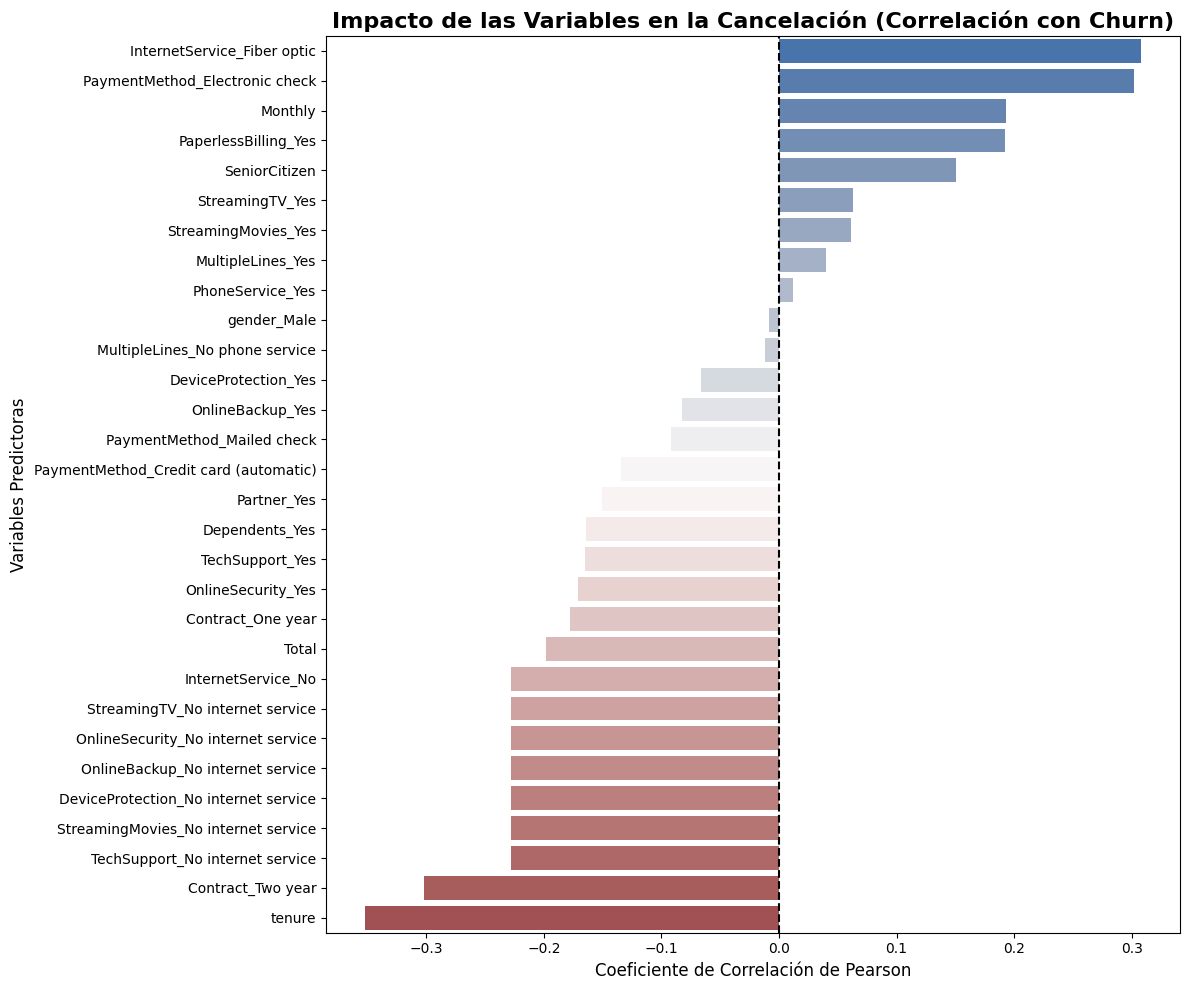

In [27]:
# 2. Visualización 1: Gráfico de barras de correlación con el Target
plt.figure(figsize=(12, 10))
# Usamos una paleta divergente: rojo para correlación positiva (peligro de abandono), azul para negativa (retención)
sns.barplot(x=correlacion_churn.values, y=correlacion_churn.index, palette='vlag')
plt.title('Impacto de las Variables en la Cancelación (Correlación con Churn)', fontsize=16, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Línea central en el 0
plt.tight_layout()
plt.show()

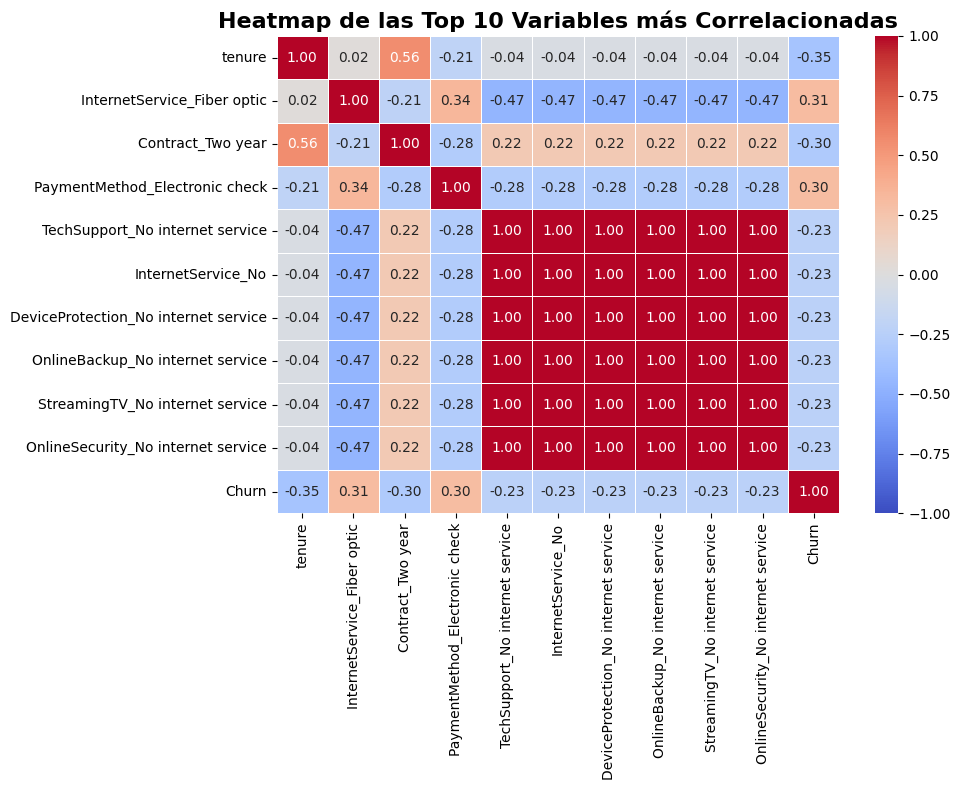

In [28]:
# 3. Visualización 2: Mapa de Calor (Heatmap) con las variables más importantes
# Seleccionamos las 10 variables con mayor correlación absoluta (ya sea positiva o negativa)
top_features = abs(correlacion_churn).sort_values(ascending=False).head(10).index.tolist()
top_features.append('Churn') # Agregamos el Target para el mapa cruzado

plt.figure(figsize=(10, 8))
# Generamos el mapa de calor
sns.heatmap(df_cleaned[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap de las Top 10 Variables más Correlacionadas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Este análisis no solo sirve para seleccionar qué columnas introduciremos a nuestros modelos, sino que ¡ya nos está dando las respuestas de negocio que la directiva necesita!